# **Product Optimization & Revenue Contribution Analysis for Afficionado Coffee Roasters**



## **Problem Statement**

Although transaction-level product data is available, Afficionado Coffee Roasters lacks:





- Clear visibility into product popularity vs profitability



- Category-level revenue dependency insights



- Identification of low-impact or underperforming menu items

Without structured product analytics, menu decisions are often intuition-driven, leading to inefficiencies and missed revenue opportunities.

## **Data Cleaning & Normalization**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import duckdb
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv('Afficionado Coffee Roasters.csv')
df

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2025,7:06:11,2,5,Lower Manhattan,32,3.00,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2025,7:08:56,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2025,7:14:04,2,5,Lower Manhattan,59,4.50,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2025,7:20:24,1,5,Lower Manhattan,22,2.00,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2025,7:22:41,2,5,Lower Manhattan,57,3.10,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
...,...,...,...,...,...,...,...,...,...,...,...
149111,149452,2025,20:18:41,2,8,Hell's Kitchen,44,2.50,Tea,Brewed herbal tea,Peppermint Rg
149112,149453,2025,20:25:10,2,8,Hell's Kitchen,49,3.00,Tea,Brewed Black tea,English Breakfast Lg
149113,149454,2025,20:31:34,1,8,Hell's Kitchen,45,3.00,Tea,Brewed herbal tea,Peppermint Lg
149114,149455,2025,20:57:19,1,8,Hell's Kitchen,40,3.75,Coffee,Barista Espresso,Cappuccino


In [3]:
df.describe()

,transaction_id,year,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116.0,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,2025.0,1.438276,5.342063,47.918607,3.382219
std,43153.600016,0.0,0.542509,2.074241,17.930020,2.658723
min,1.000000,2025.0,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,2025.0,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,2025.0,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2025.0,2.000000,8.000000,60.000000,3.750000
max,149456.000000,2025.0,8.000000,8.000000,87.000000,45.000000


In [4]:
print(f'Total Number of Duplicates: {df.duplicated().sum()}')
print(f'Total Number of Missing Values: {df.isnull().sum().sum()}')

Total Number of Duplicates: 0
Total Number of Missing Values: 0


In [5]:
products = df.loc[:,['product_id','product_category','product_type','product_detail']].drop_duplicates()
stores = df.loc[:,['store_id','store_location']].drop_duplicates()
transactions = df.drop(columns=['store_location','product_category','product_type','product_detail'])

## **Data Cleaning & Normalization Summary**

**The dataset required minimal cleaning. No duplicate records or missing values were found. Transaction quantities were verified to be positive and realistic using descriptive statistics, with no anomalies identified.**

**The dataset was then normalized into three tables Transactions, Products, and Stores. Product attributes (product_category, product_type, product_detail) were extracted into a Products table since they are properties of the product rather than the transaction. Similarly, store_location was isolated into a Stores table as it is a stable attribute of the store. The Transactions table retains all transaction-specific fields and references both tables via product_id and store_id as foreign keys. After normalization, the Products table contains 80 unique products and the Stores table contains 3 unique store locations.**

# **Exploratory Data Analysis (EDA)**

## **Product Popularity Analysis**

In [6]:
transactions['revenue'] = transactions['transaction_qty'] * transactions['unit_price']

In [7]:
def plot_revenue_by(x):
    df1 = duckdb.query(
                        f"""
                        Select {x},round(sum(transaction_qty),2) as units_sold
                        From transactions
                        Join products using(product_id)
                        group by {x}
                        """
                        ).df()

    df1 = df1.sort_values('units_sold', ascending=False)
    plt.figure(figsize=(12, 6))
    plt.bar(df1[x], df1['units_sold'])
    plt.title(f'Total units sold by {x}', fontsize=18)
    plt.xlabel(x, fontsize=14)
    plt.ylabel('Total units sold', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

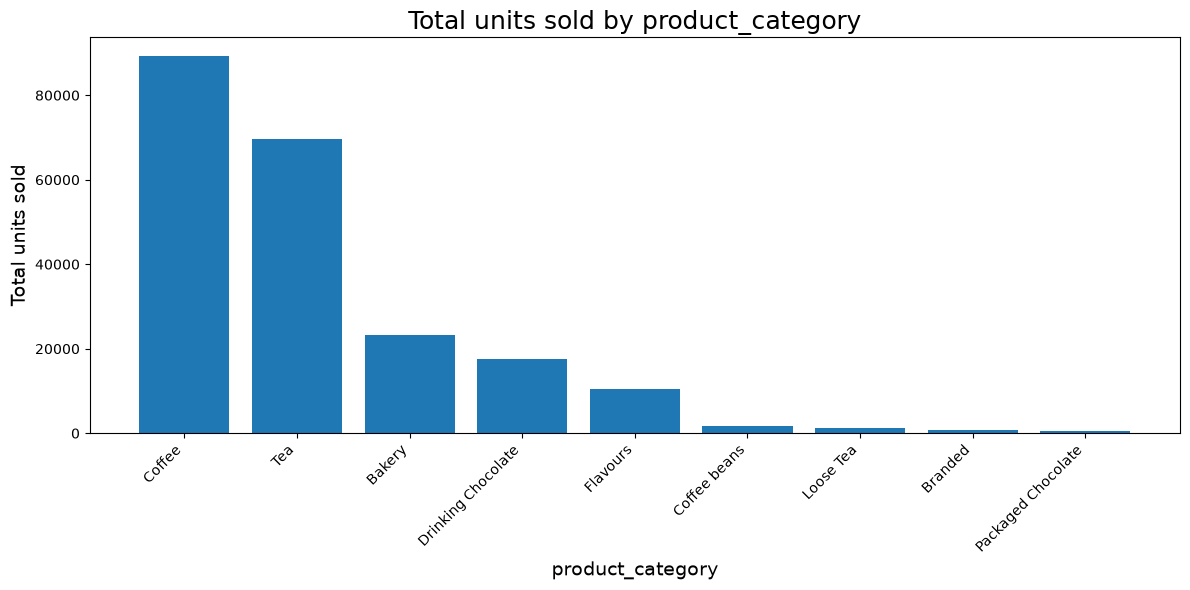

In [8]:
plot_revenue_by(x='product_category')

**Coffee is the most popular product category, followed by tea as the second most popular. Packaged Chocolate is the least sold product category overall**

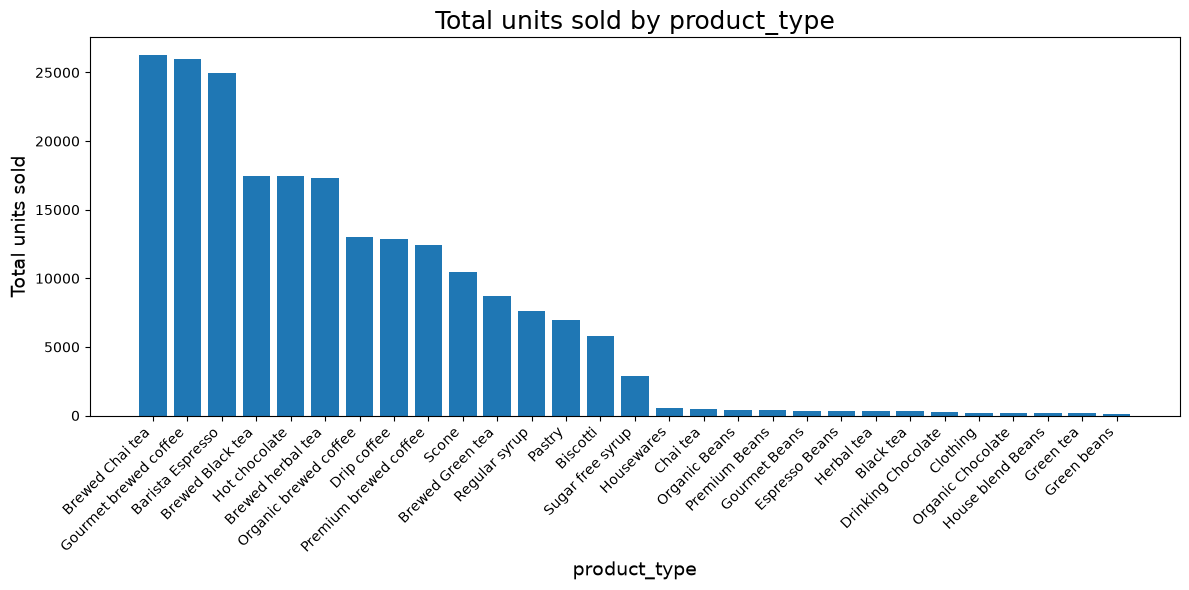

In [9]:
plot_revenue_by(x='product_type')

**Brewed Chai Tea and Gourmet Brewed Coffee are the top selling product types, followed closely by Barista Espresso. Green Beans is the least sold product type overall.**

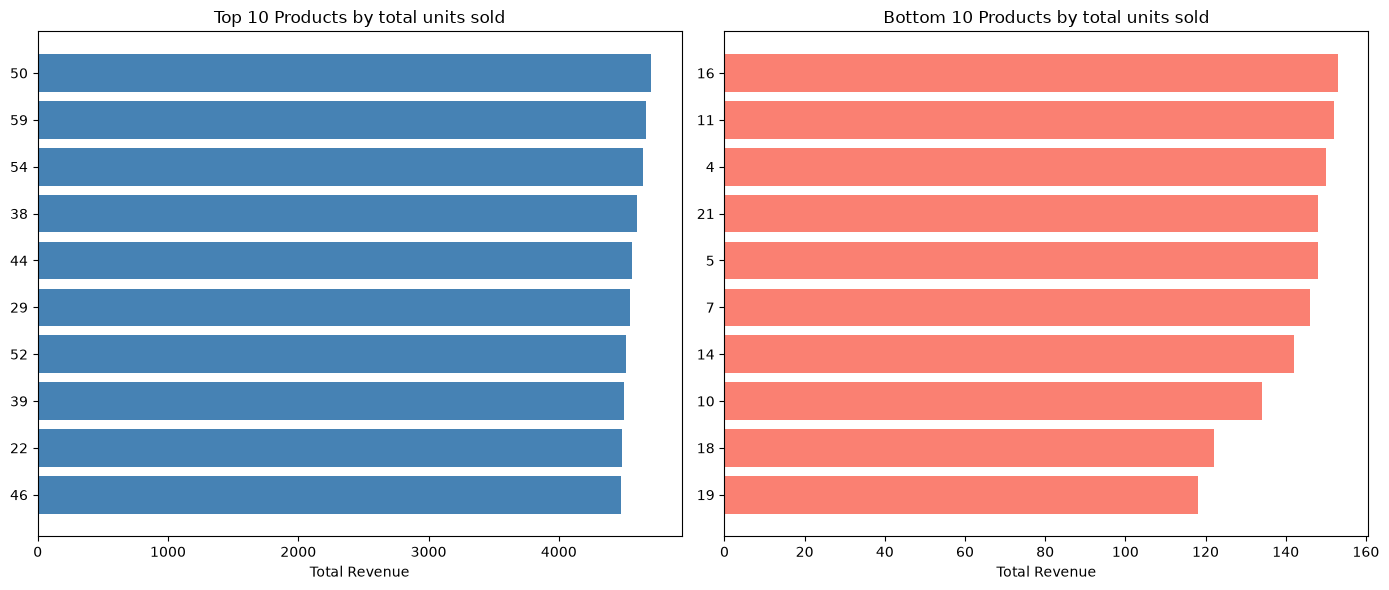

In [10]:
units_sold_df = duckdb.query(
"""
Select product_id, CAST(SUM(transaction_qty) AS INT) total_units_sold
from transactions
Join products using(product_id)
Group By product_id
order by total_units_sold desc
"""
).df()


top10 = units_sold_df.head(10).sort_values('total_units_sold').copy()
bottom10 = units_sold_df.tail(10).sort_values('total_units_sold').copy()

top10['product_id'] = top10['product_id'].astype(str)
bottom10['product_id'] = bottom10['product_id'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top10['product_id'], top10['total_units_sold'], color='steelblue')
axes[0].set_title('Top 10 Products by total units sold')
axes[0].set_xlabel('Total Revenue')

axes[1].barh(bottom10['product_id'], bottom10['total_units_sold'], color='salmon')
axes[1].set_title('Bottom 10 Products by total units sold')
axes[1].set_xlabel('Total Revenue')

plt.tight_layout()
plt.show()

**Product 50 (Earl Grey Regular Brewed Black Tea) had the highest units sold, followed by Product 59 (Dark Hot Chocolate, Large). Product 19 (Dark Chocolate, Packaged) had the least units sold overall.**

## **Revenue Analysis**

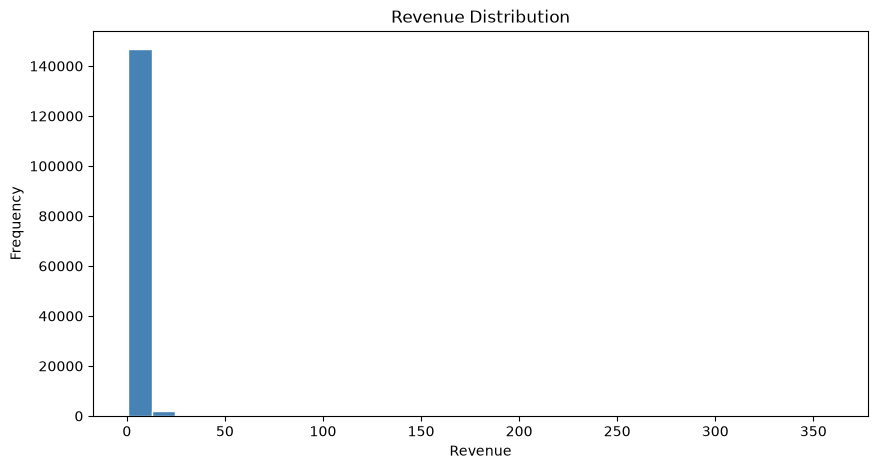

In [11]:
revenue = transactions['revenue']
mu, std = revenue.mean(), revenue.std()

x = np.linspace(revenue.min(), revenue.max(), 100)
p = stats.norm.pdf(x, mu, std)

plt.figure(figsize=(10, 5))
plt.hist(revenue, bins=30, color='steelblue', edgecolor='white')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.title('Revenue Distribution')
plt.show()


**Most transactions generate revenue between 0–30. There are a few outliers with much higher values reaching up to ~375.**

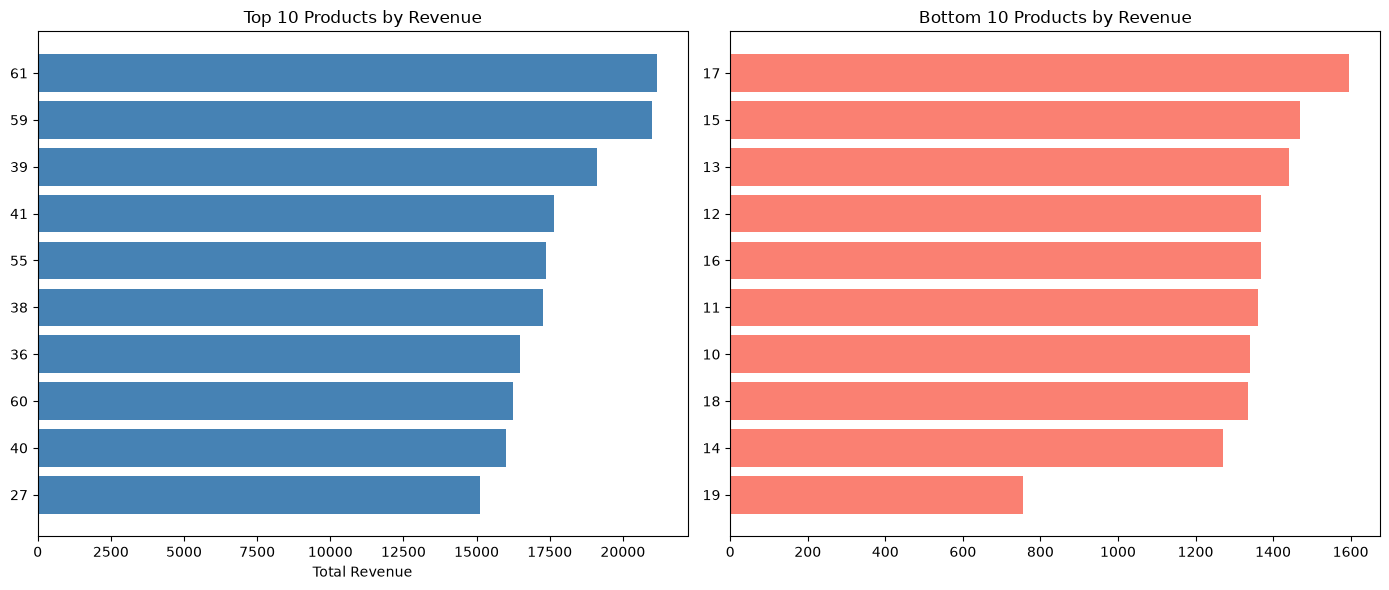

In [12]:
revenue_df = duckdb.query("""
    Select product_id, round(sum(revenue), 2) as total_revenue
    From transactions
    join products using(product_id)
    Group BY product_id
    Order By total_revenue desc
""").df()

top10 = revenue_df.head(10).sort_values('total_revenue').copy()
bottom10 = revenue_df.tail(10).sort_values('total_revenue').copy()

top10['product_id'] = top10['product_id'].astype(str)
bottom10['product_id'] = bottom10['product_id'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top10['product_id'], top10['total_revenue'], color='steelblue')
axes[0].set_title('Top 10 Products by Revenue')
axes[0].set_xlabel('Total Revenue')

axes[1].barh(bottom10['product_id'], bottom10['total_revenue'], color='salmon')
axes[1].set_title('Bottom 10 Products by Revenue')

plt.tight_layout()
plt.show()

**Product 61 (Sustainably Grown Organic Hot Chocolate, Large) generated the highest revenue, followed closely by Product 59 (Dark Hot Chocolate, Large). Product 19 (Dark Packaged Chocolate) generated the least revenue among all products.**

In [13]:
# Added volume_rank and revenue_rank to each transaction using Dense_rank()
# This allows comparison between how a product performs in units sold vs revenue generated
transactions = duckdb.query(
    """
    with cte as (
    Select product_id, sum(transaction_qty) as total_units_sold, sum(revenue) as total_revenue
    From transactions
    join products using(product_id)
    Group BY product_id),

    rnk as (
    Select *, Dense_rank() over(Order By total_units_sold desc) as volume_rank, Dense_rank() over(Order By total_revenue desc) as revenue_rank
    from products
    Join cte using(product_id))

    select t.*,r.volume_rank,r.revenue_rank
    from transactions t
    join rnk as r using(product_id)
    """).df()

transactions

,transaction_id,year,transaction_time,transaction_qty,store_id,product_id,unit_price,revenue,volume_rank,revenue_rank
0,104702,2025,7:09:45,3,5,23,2.50,7.50,13,34
1,104703,2025,7:10:48,2,8,54,2.50,5.00,3,29
2,104704,2025,7:10:51,2,3,52,2.50,5.00,7,32
3,104705,2025,7:10:51,1,3,74,3.50,3.50,53,52
4,104706,2025,7:11:49,2,3,50,2.50,5.00,1,26
...,...,...,...,...,...,...,...,...,...,...
149111,47206,2025,9:12:00,2,8,59,4.50,9.00,2,2
149112,47207,2025,9:12:41,2,8,52,2.50,5.00,7,32
149113,47208,2025,9:14:23,1,3,60,3.75,3.75,20,8
149114,47209,2025,9:15:46,1,8,54,2.50,2.50,3,29


In [14]:
corr = transactions['volume_rank'].corr(transactions['revenue_rank'])
print(f"Correlation between volume rank and revenue rank: {corr:.2f}")

Correlation between volume rank and revenue rank: 0.61


**There is a moderate positive correlation (0.61) between volume rank and revenue rank, meaning products that sell more units tend to generate more revenue, but this is not always the case. Some products perform differently in units sold versus revenue generated.**

In [15]:
duckdb.query(
"""
Select product_category, round(sum(revenue) / (select sum(revenue) from transactions),2) as total_revenue
From transactions
Join products using(product_id)
Group BY product_category
Order by total_revenue desc
"""
).df()

,product_category,total_revenue
0,Coffee,0.39
1,Tea,0.28
2,Bakery,0.12
3,Drinking Chocolate,0.10
4,Coffee beans,0.06
5,Branded,0.02
6,Loose Tea,0.02
7,Flavours,0.01
8,Packaged Chocolate,0.01


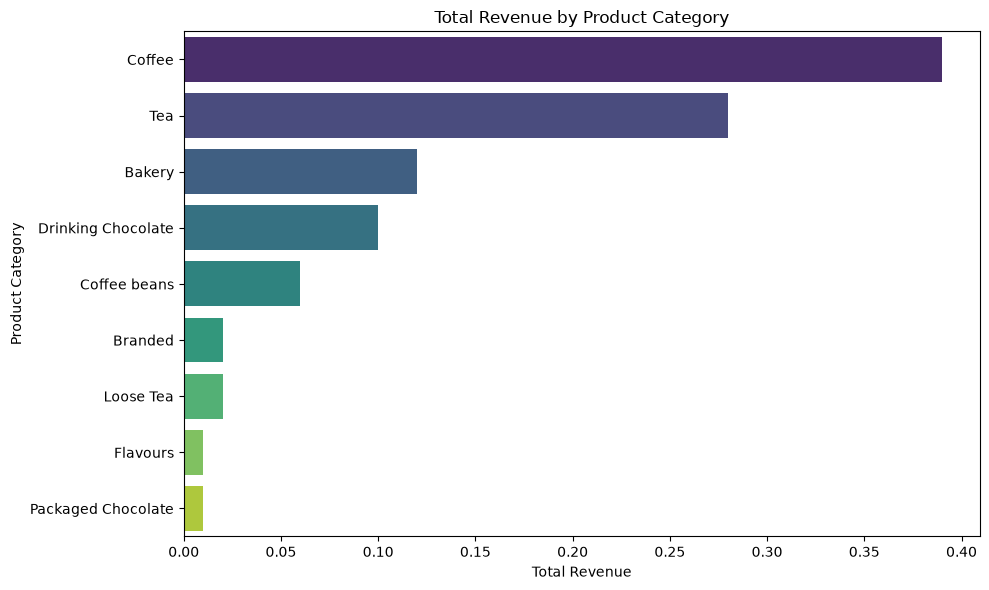

In [16]:
df = duckdb.query(
"""
Select product_category, round(sum(revenue) / (select sum(revenue) from transactions),2) as total_revenue
From transactions
Join products using(product_id)
Group BY product_category
Order by total_revenue desc
"""
).df()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x="total_revenue",
    y="product_category",
    hue="product_category",
    palette="viridis",
    legend=False
)

plt.title("Total Revenue by Product Category")
plt.xlabel("Total Revenue")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

**Coffee accounts for 39% of total revenue, making it the highest contributing product category, followed by Tea at 28%. All other categories contribute significantly less, with Bakery third at 12% and Flavours contributing the least overall.**

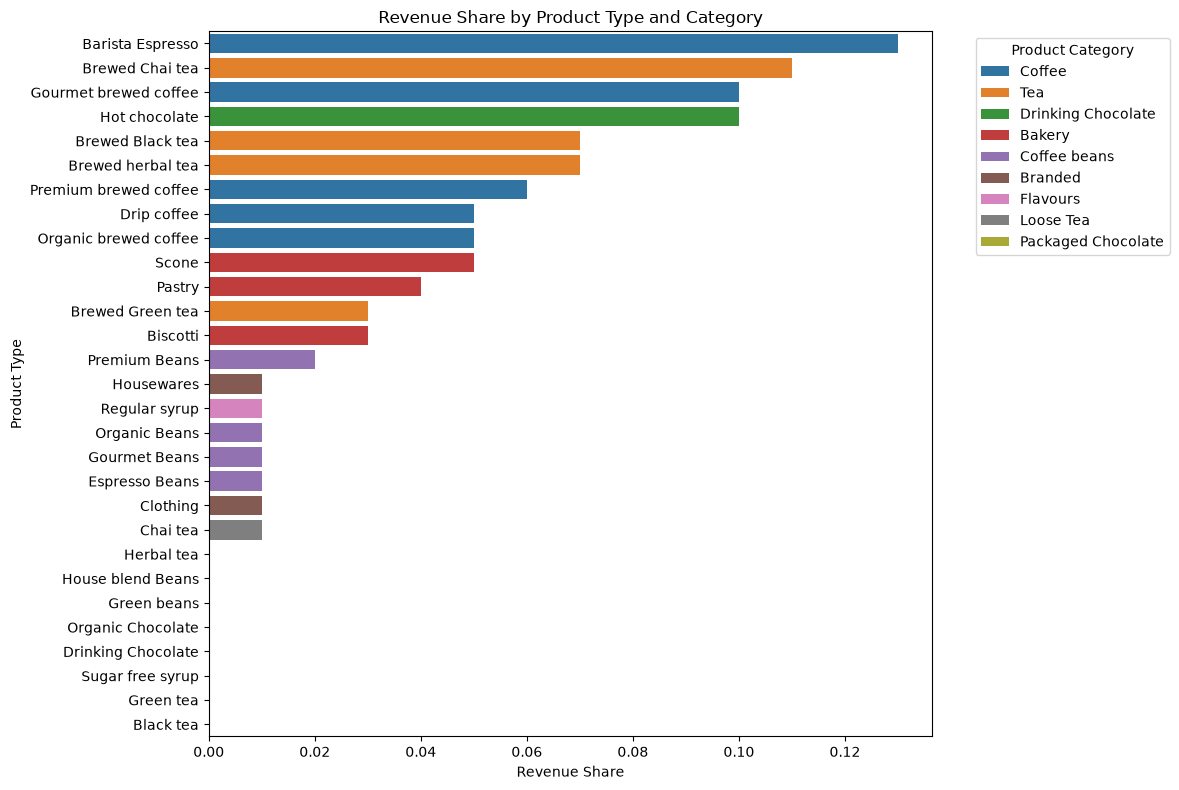

In [17]:
df = duckdb.query(
"""
Select product_category, product_type, round(sum(revenue) / (select sum(revenue) from transactions),2) as total_revenue
From transactions
Join products using(product_id)
Group BY product_category, product_type
Order by total_revenue desc
"""
).df()

plt.figure(figsize=(12, 8))
sns.barplot(data=df, y='product_type', x='total_revenue', hue='product_category')
plt.title('Revenue Share by Product Type and Category')
plt.xlabel('Revenue Share')
plt.ylabel('Product Type')
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

**Barista Espresso is the highest revenue generating coffee type at 13% share, followed by Brewed Chai Tea as the top performing tea type at 10%, with Gourmet Brewed Coffee close behind. Hot Chocolate is the top performing Drinking Chocolate type also at 10%. Product types such as Green Tea, Black Tea, Herbal Tea, and Green Beans contribute negligible revenue share overall.**

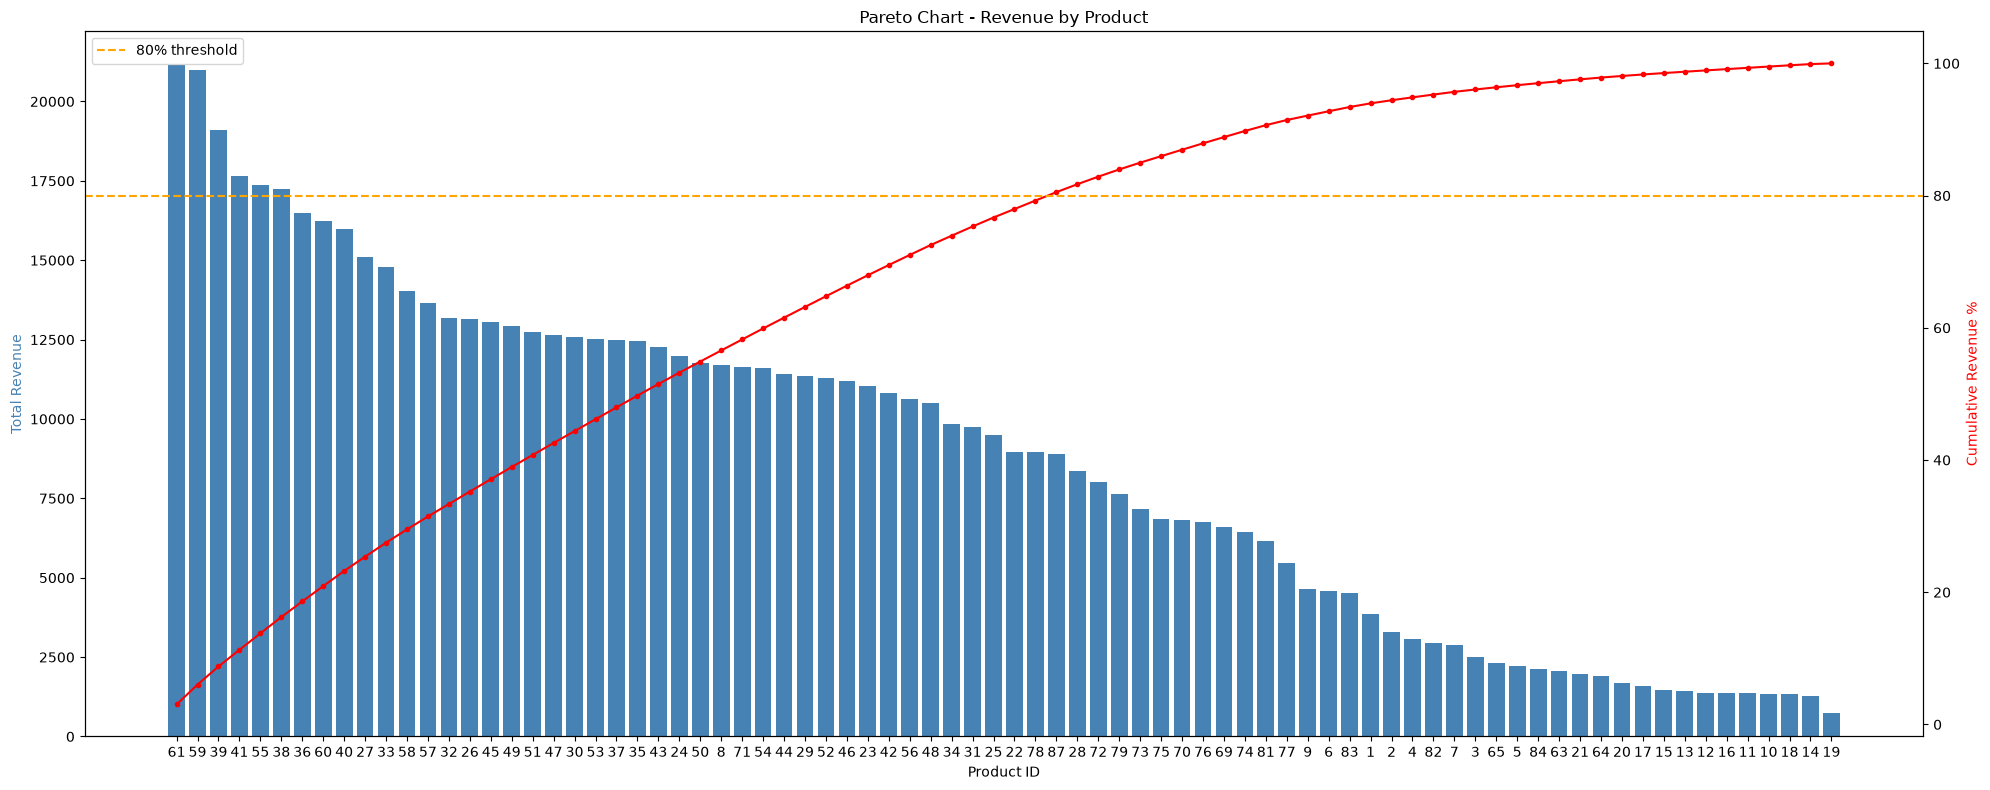

In [18]:
revenue_by_product = duckdb.query("""
    Select product_id, round(sum(revenue),2) as total_revenue
    from transactions
    group by product_id
    order by total_revenue desc
""").df()

revenue_by_product['cumulative_pct'] = (revenue_by_product['total_revenue'].cumsum() / revenue_by_product['total_revenue'].sum() * 100)

fig, ax1 = plt.subplots(figsize=(20, 8))

ax1.bar(revenue_by_product['product_id'].astype(str), revenue_by_product['total_revenue'], color='steelblue')
ax1.set_xlabel('Product ID')
ax1.set_ylabel('Total Revenue', color='steelblue')

ax2 = ax1.twinx()
ax2.plot(revenue_by_product['product_id'].astype(str), revenue_by_product['cumulative_pct'], color='red', marker='o', markersize=3)
ax2.axhline(80, color='orange', linestyle='--', label='80% threshold')
ax2.set_ylabel('Cumulative Revenue %', color='red')
ax2.legend()

plt.title('Pareto Chart - Revenue by Product')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**The Pareto chart shows that approximately the top 40 products (out of 80) account for 80% of total revenue, with Product 61 and 59 serving as the strongest revenue anchors. This indicates revenue is fairly evenly spread across products rather than being driven by a small group. The remaining 40 products form a long tail of minimal contributors, each generating relatively little revenue individually but collectively making up the final 20%.**

## **KPI'S**

In [19]:
total_revenue = round(transactions['revenue'].sum(),2)
total_units = transactions['transaction_qty'].sum()
average_revenue = transactions.groupby('product_id')['revenue'].mean()

In [20]:
revenue_ratio = duckdb.query(
    """
    With cte as (Select product_id, sum(revenue) / (select sum(revenue) From transactions) as revenue_ratio
    From transactions
    Group by product_id
    Order by revenue_ratio desc
    Limit 10)

    Select round(sum(revenue_ratio) * 100,2) as revenue_ratio
    From cte
    """
).fetchall()[0][0]

In [26]:
print(f"Total Revenue: {total_revenue}")
print(f"Total Units Sold: {total_units}")
print(f"Average Revenue per Product: {average_revenue.mean():.2f}")
print(f"Top 10 Products Revenue Contribution: {revenue_ratio}%")

Total Revenue: 698812.33
Total Units Sold: 214470
Average Revenue per Product: 7.69
Top 10 Products Revenue Contribution: 25.38%
